In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/Crash_Reporting_-_Non-Motorists_Data_20260310 (1).csv', low_memory=False)
df[:5]

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Pedestrian Type,Pedestrian Movement,Pedestrian Actions,Pedestrian Location,At Fault,Injury Severity,Safety Equipment,Latitude,Longitude,Location
0,MCP26350094,260009207,MONTGOMERY,Fatal Crash,03/01/2026 06:30:00 PM,Municipality Route,AVERY RD,NORBECK RD,NaN,NaN,...,Pedestrian,Unknown,Unknown,Unknown,No,Fatal Injury,NaN,39.092816,-77.122717,"(39.09281566, -77.12271671)"
1,MCP2460002K,260009046,MONTGOMERY,Injury Crash,02/28/2026 05:14:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT WAY OF 9651...,NaN,...,Pedestrian,Other,None (No Improper Action),Other,No,Possible Injury,NaN,39.153768,-77.197923,"(39.15376787, -77.19792279)"
2,MCP2460002K,260009046,MONTGOMERY,Injury Crash,02/28/2026 05:14:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT WAY OF 9651...,NaN,...,Pedestrian,Other,None (No Improper Action),Other,No,Possible Injury,NaN,39.153768,-77.197923,"(39.15376787, -77.19792279)"
3,MCP2460002K,260009046,MONTGOMERY,Injury Crash,02/28/2026 05:14:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT WAY OF 9651...,NaN,...,Pedestrian,Other,None (No Improper Action),Other,No,Suspected Minor Injury,NaN,39.153768,-77.197923,"(39.15376787, -77.19792279)"
4,MCP316300B4,260008758,MONTGOMERY,Injury Crash,02/26/2026 06:27:00 PM,Maryland (State) Route,PLYERS MILL RD,CONNECTICUT AVE,NaN,NaN,...,Scooter (electric),Walking/Cycling on Sidewalk,"Not Visible (Dark Clothing, No Lighting, etc.)",Intersection Marked Crosswalk,No,Suspected Minor Injury,NaN,39.029758,-77.075770,"(39.0297585, -77.07576983)"


In [24]:
# Cleaning (Time/Redundancy/Other Concerns)
df['Crash Date/Time'] = pd.to_datetime(df['Crash Date/Time'])
df['Year'] = df['Crash Date/Time'].dt.year
df['Hour'] = df['Crash Date/Time'].dt.hour
# Functions
def consolidate_non_motorist(val):
    if pd.isna(val): return 'Unknown'
    v = str(val).upper()
    if 'PEDESTRIAN' in v: return 'Pedestrian'
    if 'CYCLIST' in v or 'BICYCLIST' in v or 'PEDALCYCLIST' in v: return 'Cyclist'
    if 'SCOOTER' in v: return 'Scooter'
    if 'WHEELCHAIR' in v: return 'Wheelchair'
    return 'Other'

def check_substance(val):
    if pd.isna(val): return "Unknown"
    v = str(val).lower()
    if "suspect" in v and "not suspect" not in v: return "Substance Suspected"
    if "alcohol" in v or "drug" in v: return "Substance Suspected"
    return "Not Suspect"

def clean_light(val):
    if pd.isna(val): return 'Unknown'
    v = str(val).upper()
    if 'DAYLIGHT' in v: return 'Daylight'
    if 'DARK' in v and ('LIGHTED' in v or 'LIGHTS ON' in v): return 'Dark - Lighted'
    if 'DARK' in v and ('NO LIGHTS' in v or 'NOT LIGHTED' in v): return 'Dark - No Lights'
    return v.title()
# Substance
df['Cleaned Type'] = df['Related Non-Motorist'].apply(consolidate_non_motorist)
df['Substance Flag'] = df['Driver Substance Abuse'].apply(check_substance)
df['Cleaned Light'] = df['Light'].apply(clean_light)
df['Weather'] = df['Weather'].str.strip().str.title().replace('Raining', 'Rain')
df['At Fault'] = df['At Fault'].fillna('Unknown').str.strip().str.title()

/tmp/ipykernel_3118/911493444.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Crash Date/Time'] = pd.to_datetime(df['Crash Date/Time'])


In [25]:
# Filter for year
df_clean = df[df['Year'] <= 2025].copy()
df_fatal = df_clean[df_clean['ACRS Report Type'] == 'Fatal Crash'].copy()

In [26]:
# Pivot Tables
at_fault_pivot = pd.pivot_table(df_clean, index='Cleaned Type', columns='At Fault',
                                values='Report Number', aggfunc='count', fill_value=0)
at_fault_pivot['Total'] = at_fault_pivot.sum(axis=1)

# Weather Pivot for Fatal Crashes
weather_pivot = pd.pivot_table(df_fatal, index='Weather', values='Report Number',
                               aggfunc='count').sort_values('Report Number', ascending=False)
weather_pivot


,Report Number
Weather,
Clear,125
Rain,22
Cloudy,7
Severe Winds,2
"Fog, Smog, Smoke",1


In [27]:
at_fault_pivot

At Fault,No,Unknown,Yes,Total
Cleaned Type,,,,
Cyclist,925,136,438,1499
Other,278,47,92,417
Pedestrian,3257,541,1234,5032
Scooter,65,0,24,89
Wheelchair,9,0,2,11


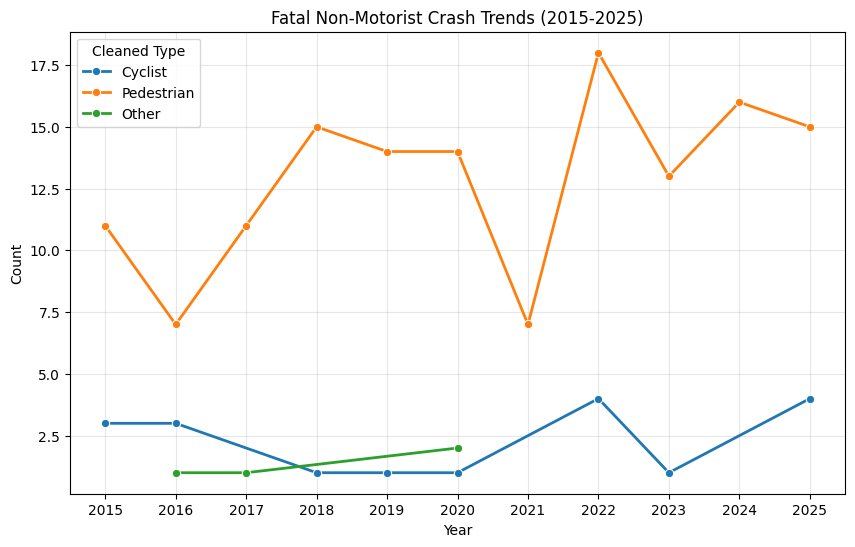

In [28]:
# Fatality Line Graph
plt.figure(figsize=(10, 6))
fatal_trends = df_fatal.groupby(['Year', 'Cleaned Type']).size().reset_index(name='Count')
sns.lineplot(data=fatal_trends, x='Year', y='Count', hue='Cleaned Type', marker='o', linewidth=2)
plt.title('Fatal Non-Motorist Crash Trends (2015-2025)')
plt.xticks(range(2015, 2026))
plt.grid(True, alpha=0.3)

Text(0.5, 1.0, 'Crashes by Hour: Substance Suspected vs Not Suspected')

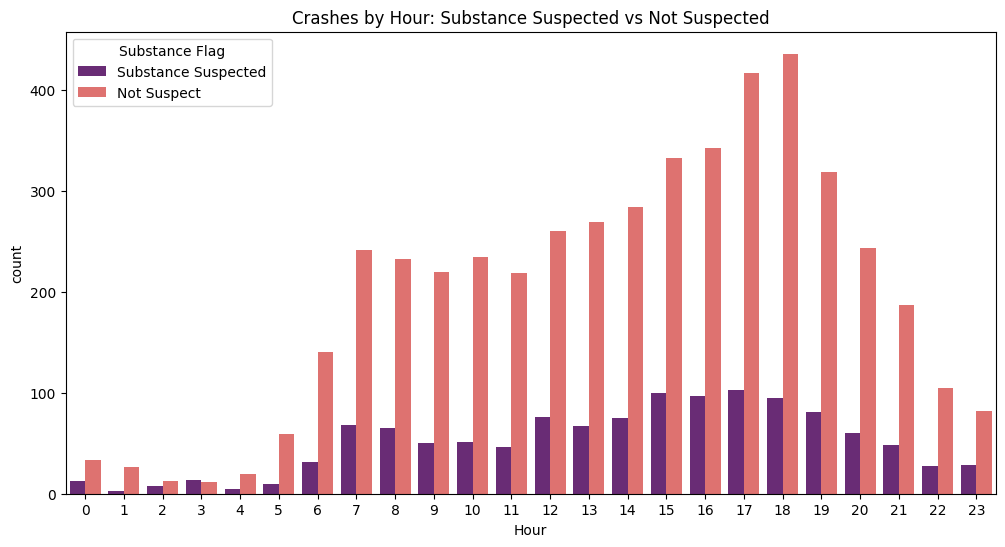

In [29]:
# Substance Use
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean[df_clean['Substance Flag'] != 'Unknown'],
              x='Hour', hue='Substance Flag', palette='magma')
plt.title('Crashes by Hour: Substance Suspected vs Not Suspected')

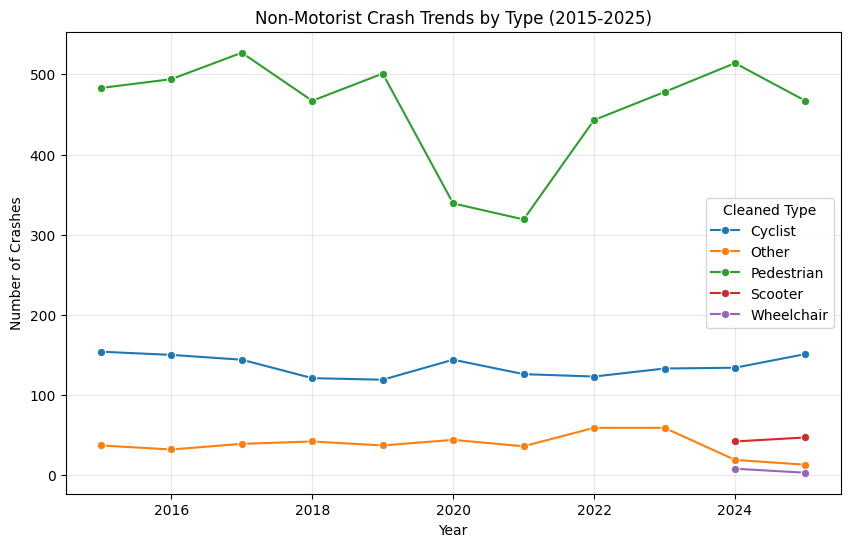

In [30]:
# Non Motorist Count Trends
trend_data2 = df_clean.groupby(['Year', 'Cleaned Type']).size().reset_index(name='Count')
plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_data2, x='Year', y='Count', hue='Cleaned Type', marker='o')
plt.title('Non-Motorist Crash Trends by Type (2015-2025)')
plt.ylabel('Number of Crashes')
plt.grid(True, alpha=0.3)

/tmp/ipykernel_3118/3139774767.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=at_fault_counts.index, y=at_fault_counts.values, palette='viridis')


Text(0, 0.5, 'Count')

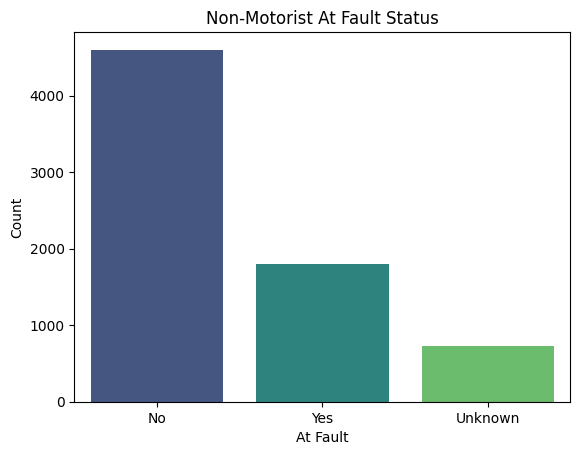

In [31]:
at_fault_counts = df['At Fault'].value_counts()
sns.barplot(x=at_fault_counts.index, y=at_fault_counts.values, palette='viridis')
plt.title('Non-Motorist At Fault Status')
plt.ylabel('Count')

In [32]:
# Pivot Version 2
weather_pivot = pd.pivot_table(fatal_df,
                               index='Weather',
                               values='Report Number',
                               aggfunc='count')
weather_pivot

,Report Number
Weather,
Clear,125
Cloudy,7
"Fog, Smog, Smoke",1
Rain,22
Severe Winds,2
